### Exploring the influence of the regularization parameter in a context of a signal chirp function

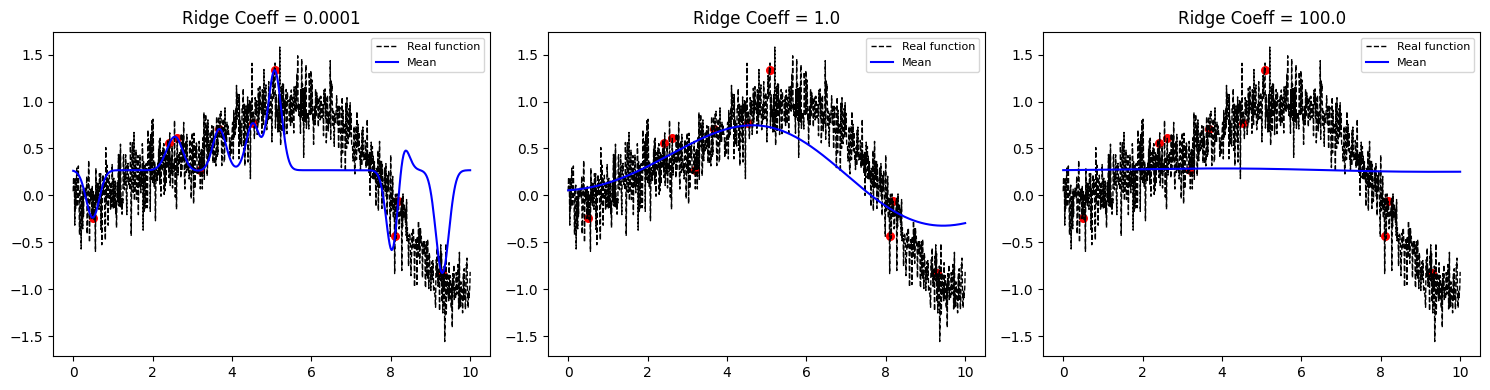

In [64]:
import matplotlib.pyplot as plt
import sys
import numpy as np
sys.path.insert(0, '..')
from kernax.stationary import SEKernel
import KRR
import random

kernel = SEKernel(1.0)

X = np.linspace(0, 10, 1000).reshape(-1, 1)
#Signal chirp, the function is interesting because we will really see the influence
# of the ridge coefficient
y = np.sin(0.5*X.ravel() **2 / 10) + 0.2 * np.random.randn(X.shape[0]) 
rng = np.random.RandomState(1)
training_indices = rng.choice(X.shape[0], size=10, replace=False)
X_train, y_train = X[training_indices], y[training_indices]
RidgeValues = [1e-4,1.0,100.0]
X_plot = np.linspace(0, 10, 400).reshape(-1,1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for (a,ridge), ax in zip(enumerate(RidgeValues),axes):
    KRRClass = KRR.KRR(X_train, Kernel=kernel, RidgeCoeff=ridge, NormalizeObs=True).fit(y_train)
    PosteriorFunction = KRRClass.predict(X_plot)
    ax.plot(X, y, 'k--', lw=1, label='Real function')
    x_plot = X_train.ravel().astype(float)
    y_plot = y_train.ravel().astype(float)
    ax.scatter(x_plot, y_plot, c='red', s=30)
    ax.plot(X_plot, PosteriorFunction, 'b-', label='Mean')
    ax.set_title(f'Ridge Coeff = {ridge}')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()




# Simple comparison of the behavior of Square Exponential, Matern, and Periodic Kernel

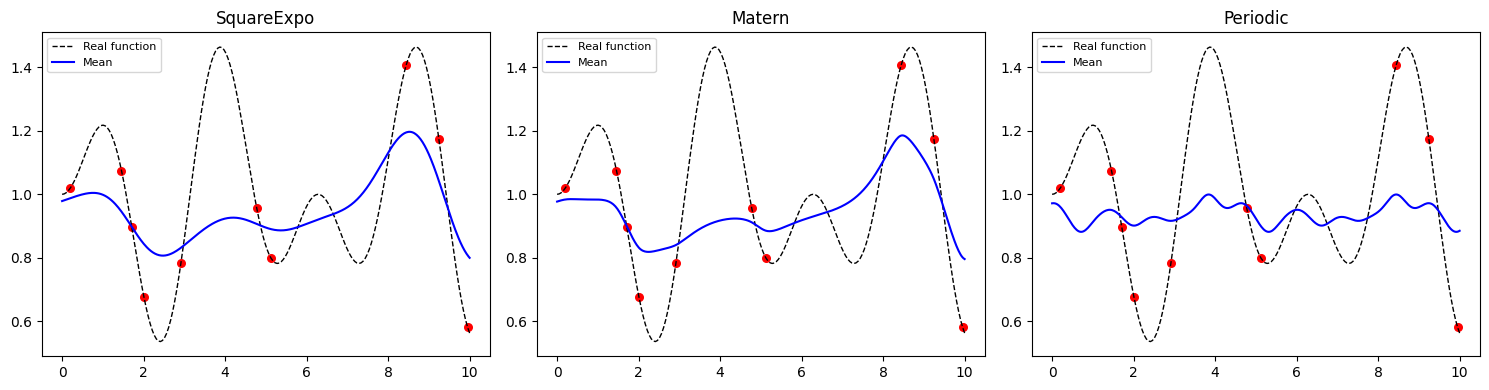

In [65]:
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '..')
from kernax.stationary import SEKernel, Matern32Kernel, PeriodicKernel
import numpy as np
import KRR

kernels = {
    'SquareExpo': SEKernel(1.0),
    'Matern': Matern32Kernel(1.0),
    'Periodic': PeriodicKernel(1.0, 1.0, 5.0)
}

X = np.linspace(0, 10, 200).reshape(-1, 1)
y = 1 + 0.5*np.sin(0.5*X.ravel()) * np.sin(2*X.ravel())
rng = np.random.RandomState(1)
#We choose randomly the observations 
training_indices = rng.choice(np.arange(y.size), size=10, replace=False)
X_train, y_train = X[training_indices], y[training_indices]

X_plot = np.linspace(0, 10, 400).reshape(-1,1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, kern) in zip(axes, kernels.items()):
    KRRClass = KRR.KRR(X_train, Kernel=kern,RidgeCoeff=1.0,NormalizeObs=True).fit(y_train)

    #Prediction of the points produced by X_Plot
    PosteriorFunction = KRRClass.predict(X_plot)
    ax.plot(X, y, 'k--', lw=1, label='Real function') 
    ax.scatter(X_train, y_train, c='red', s=30)
    ax.plot(X_plot, PosteriorFunction, 'b-', label='Mean')
    #Normalization 
    ax.set_title(name)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Comparison between a KRR and a GP 

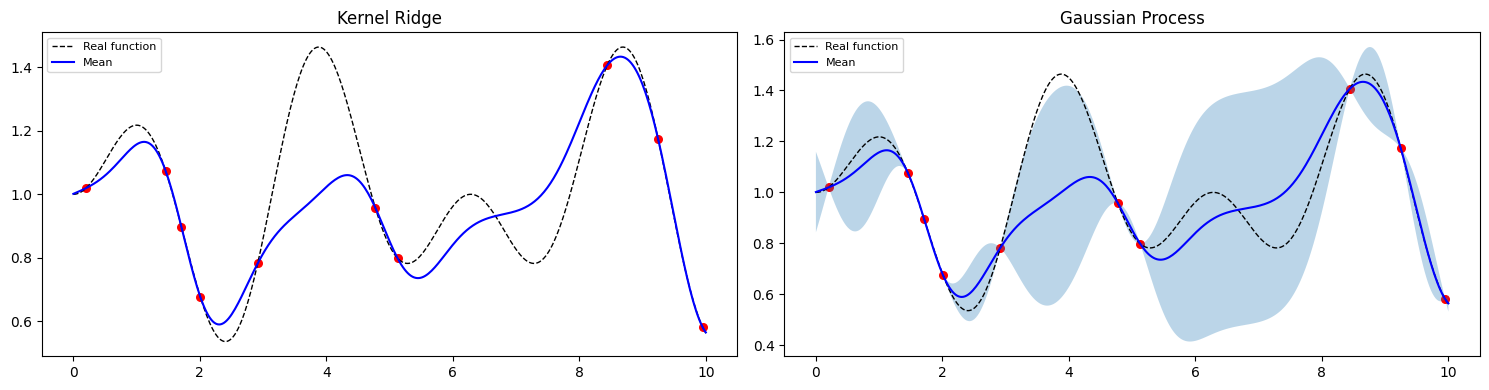

In [ ]:
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '..')
from kernax.stationary import SEKernel, Matern32Kernel, PeriodicKernel
import numpy as np
import KRR, GP

kern = SEKernel(1.0)
X = np.linspace(0, 10, 200).reshape(-1, 1)
y = 1 + 0.5*np.sin(0.5*X.ravel()) * np.sin(2*X.ravel())
rng = np.random.RandomState(1)
#We choose randomly the observations 
training_indices = rng.choice(np.arange(y.size), size=10, replace=False)
X_train, y_train = X[training_indices], y[training_indices]

X_plot = np.linspace(0, 10, 400).reshape(-1,1)
fig,(ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))
LimitY = (0.4,1.6)
ax1.set_ylim(LimitY)
ax2.set_ylim(LimitY)

KRRClass = KRR.KRR(X_train, Kernel=kern,RidgeCoeff=1e-5,NormalizeObs=True).fit(y_train)
y_plot = 1 + 0.5*np.sin(0.5*X_plot.ravel()) * np.sin(2*X_plot.ravel())
    #Prediction of the points produced by X_Plot
PosteriorFunction = KRRClass.predict(X_plot)
ax1.plot(X_plot, y_plot, 'k--', lw=1, label='Real function') 
ax1.scatter(X_train, y_train, c='red', s=30)
ax1.plot(X_plot, PosteriorFunction, 'b-', label='Mean')
    #Normalization 
ax1.set_title('Kernel Ridge')
ax1.legend(fontsize=8)

gp = GP.GP(Kernel=kern,Alpha=1e-5,NormalizeObs=True).fit(X_train,y_train)

    #Prediction of the points produced by X_Plot
meanGP, stdGP = gp.predict(X_plot,Return_std=True)
ax2.plot(X_plot, y_plot, 'k--', lw=1, label='Real function') 
ax2.scatter(X_train, y_train, c='red', s=30)
ax2.plot(X_plot, meanGP, 'b-', label='Mean')
ax2.fill_between(X_plot.ravel(), meanGP-1.96*stdGP, meanGP+1.96*stdGP, alpha=0.3)
    #Normalization 
ax2.set_title('Gaussian Process')
ax2.legend(fontsize=8)



plt.tight_layout()
plt.show()

In [67]:
')
ax1.legend(fontsize=8)

gp = GP.GP(Kernel=kern).fit(X_train,y_train)

    #Prediction of the points produced by X_Plot
meanGP, stdGP = gp.predict(X_plot,Return_std=True)
ax2.plot(X, y, 'k--', lw=1, label='Real function') 
ax2.scatter(X_train, y_train, c='red', s=30)
ax2.plot(X_plot, meanGP, 'b-', label='Mean')
ax2.fill_between(X_plot.ravel(), meanGP-1.96*stdGP, meanGP+1.96*stdGP, alpha=0.3)
    #Normalization 
ax2.set_title('Gaussian Process')
ax2.legend(fontsize=8)



plt.tight_layout()
plt.show()

SyntaxError: unterminated string literal (detected at line 1) (3620713009.py, line 1)